In [1]:
import pandas as pd
df=pd.read_excel("QVI_transaction_data.xlsx")
df.head(5)


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [2]:
df.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [3]:
df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [4]:
#check for negative sales

df[df["TOT_SALES"]<0]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


### From above code , there is no negative sales

In [5]:
# check datatype of every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [6]:
# here date is in wrong datatype so convert it into date-time datatype

df["DATE"] = pd.to_datetime(df["DATE"], origin="1899-12-30", unit="D")

In [7]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [8]:
df["DATE"].min(), df["DATE"].max()

(Timestamp('2018-07-01 00:00:00'), Timestamp('2019-06-30 00:00:00'))

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df[df.duplicated()]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124845,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

### check for incorrect entries

In [14]:
df[df["PROD_QTY"]<0]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


In [15]:
df[df["TOT_SALES"]<0]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


In [16]:
df["Pack_Size"]=df["PROD_NAME"].str.extract(r'(\d+)\s*[gG]')
df["Pack_Size"]

0         175
1         175
2         170
3         175
4         150
         ... 
264831    175
264832    175
264833    170
264834    150
264835    175
Name: Pack_Size, Length: 264835, dtype: object

In [17]:
df["Pack_Size"]=df["Pack_Size"].astype(float)

In [18]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0


In [19]:
df["PROD_NAME"].unique()

array(['Natural Chip        Compny SeaSalt175g',
       'CCs Nacho Cheese    175g',
       'Smiths Crinkle Cut  Chips Chicken 170g',
       'Smiths Chip Thinly  S/Cream&Onion 175g',
       'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
       'Old El Paso Salsa   Dip Tomato Mild 300g',
       'Smiths Crinkle Chips Salt & Vinegar 330g',
       'Grain Waves         Sweet Chilli 210g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Grain Waves Sour    Cream&Chives 210G',
       'Kettle Sensations   Siracha Lime 150g',
       'Twisties Cheese     270g', 'WW Crinkle Cut      Chicken 175g',
       'Thins Chips Light&  Tangy 175g', 'CCs Original 175g',
       'Burger Rings 220g', 'NCC Sour Cream &    Garden Chives 175g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Cheezels Cheese Box 125g', 'Smiths Crinkle      Original 330g',
       'Infzns Crn Crnchers Tangy Gcamole 110g',
       'Kettle Sea Salt     And Vinegar 175g',
       'Smiths Chip Thinly  Cut Original 175g', 'K

In [20]:
df["PROD_NAME"] = df["PROD_NAME"].str.upper()

In [21]:
brands = [
    "KETTLE", "SMITHS", "DORITOS", "PRINGLES", "RRD",
    "RED ROCK DELI", "THINS", "TWISTIES", "TOSTITOS",
    "INFUZIONS", "COBS", "TYRRELLS", "GRAIN WAVES",
    "CHEEZELS", "CCS", "CHEETOS", "WOOLWORTHS",
    "WW", "NATURAL CHIP ", "SUNBITES"
]

In [22]:
def extract_brand(name):
    for brand in brands:
        if brand in name:
            return brand
    return "Others"

df["Brand"]=df["PROD_NAME"].apply(extract_brand)
        

In [23]:
df["Brand"].unique()

array(['NATURAL CHIP ', 'CCS', 'SMITHS', 'KETTLE', 'Others',
       'GRAIN WAVES', 'DORITOS', 'TWISTIES', 'WW', 'THINS', 'CHEEZELS',
       'RED ROCK DELI', 'PRINGLES', 'INFUZIONS', 'TYRRELLS', 'COBS',
       'WOOLWORTHS', 'RRD', 'TOSTITOS', 'CHEETOS', 'SUNBITES'],
      dtype=object)

In [24]:
df["Brand"] = df["Brand"].replace({
    "RRD": "RED ROCK DELI",
    "WW": "WOOLWORTHS",
    "Others": "OTHER"
})

In [25]:
df["Brand"].unique()

array(['NATURAL CHIP ', 'CCS', 'SMITHS', 'KETTLE', 'OTHER', 'GRAIN WAVES',
       'DORITOS', 'TWISTIES', 'WOOLWORTHS', 'THINS', 'CHEEZELS',
       'RED ROCK DELI', 'PRINGLES', 'INFUZIONS', 'TYRRELLS', 'COBS',
       'TOSTITOS', 'CHEETOS', 'SUNBITES'], dtype=object)

In [26]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,Brand
0,2018-10-17,1,1000,1,5,NATURAL CHIP COMPNY SEASALT175G,2,6.0,175.0,NATURAL CHIP
1,2019-05-14,1,1307,348,66,CCS NACHO CHEESE 175G,3,6.3,175.0,CCS
2,2019-05-20,1,1343,383,61,SMITHS CRINKLE CUT CHIPS CHICKEN 170G,2,2.9,170.0,SMITHS
3,2018-08-17,2,2373,974,69,SMITHS CHIP THINLY S/CREAM&ONION 175G,5,15.0,175.0,SMITHS
4,2018-08-18,2,2426,1038,108,KETTLE TORTILLA CHPSHNY&JLPNO CHILI 150G,3,13.8,150.0,KETTLE


In [27]:
df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
Pack_Size         0
Brand             0
dtype: int64

In [28]:
df["Pack_Size"].fillna(df["Pack_Size"].median,inplace=True)

In [29]:
df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
Pack_Size         0
Brand             0
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x1ef0e75a0d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1ef0e75a350>,
 'boxes': [<matplotlib.lines.Line2D at 0x1ef0e691f90>],
 'medians': [<matplotlib.lines.Line2D at 0x1ef0e75a5d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1ef0e75a710>],
 'means': []}

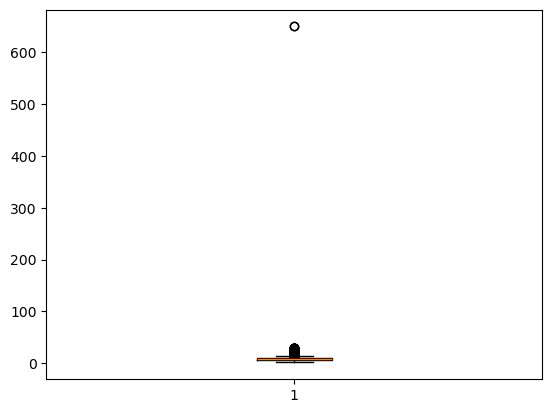

In [30]:
##check for outlier

import matplotlib.pyplot as plt
plt.boxplot(df["TOT_SALES"])

In [31]:
##here there are outlier above 600 so check that those buyers are premium or lower

##if lower then remove 

df[df["TOT_SALES"]>600][["TOT_SALES","PROD_QTY"]]

,TOT_SALES,PROD_QTY
69762,650.0,200
69763,650.0,200


### Both are premium buyer because it buy in bulk so not to remove this


In [32]:
print("Final Shape:", df.shape)
print("Null Values:\n", df.isnull().sum())

Final Shape: (264835, 10)
Null Values:
 DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
Pack_Size         0
Brand             0
dtype: int64


In [33]:
df.to_csv("clean_transaction.csv",index=False)